# 03 · Deep Learning con PyTorch

> 🇬🇧 English version: [`03_pytorch_en.ipynb`](03_pytorch_en.ipynb)

PyTorch te da tres piezas fundamentales:

1. **Tensores**: como arrays de NumPy, pero pueden vivir en GPU.
2. **Autograd**: calcula gradientes automáticamente (backpropagation).
3. **`torch.nn` + `torch.optim`**: capas, funciones de pérdida y optimizadores.

A diferencia de scikit-learn, **el ciclo de entrenamiento lo escribes tú**. Al final resolvemos el mismo
problema de precios de casas y comparamos con el notebook 02.

In [1]:
# Librerias a usar
#=====================================================
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| dispositivo:", dispositivo)

torch 2.14.0+cu130 | dispositivo: cpu


## 1. Tensores

In [2]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.ones(2, 2)

print(a + b)            # elemento a elemento
print(a @ b)            # producto matricial
print(a.shape, a.dtype)
print(a.numpy())        # a NumPy (comparten memoria en CPU)
print(torch.from_numpy(np.arange(3)))

tensor([[2., 3.],
        [4., 5.]])
tensor([[3., 3.],
        [7., 7.]])
torch.Size([2, 2]) torch.float32
[[1. 2.]
 [3. 4.]]
tensor([0, 1, 2])


## 2. Autograd

Si un tensor tiene `requires_grad=True`, PyTorch registra las operaciones y `backward()` calcula derivadas.
Para $y = x^2 + 3x$, la derivada en $x=2$ es $2x + 3 = 7$.

In [3]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3 * x
y.backward()
print(x.grad)

tensor(7.)


## 3. Regresión lineal "a mano" con autograd

Descenso de gradiente sobre datos sintéticos $y = 3x + 2 + \\text{ruido}$. Es lo que hiciste *from scratch*
en `03_ml_from_scratch`, pero sin derivar a mano.

In [4]:
X_toy = torch.linspace(-1, 1, 100).unsqueeze(1)
y_toy = 3 * X_toy + 2 + 0.2 * torch.randn_like(X_toy)

w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.1

for epoca in range(200):
    pred = X_toy * w + b
    perdida = ((pred - y_toy) ** 2).mean()
    perdida.backward()          # calcula dL/dw y dL/db
    with torch.no_grad():       # actualizar sin registrar en el grafo
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_(); b.grad.zero_()

print(f"w = {w.item():.3f} (real 3), b = {b.item():.3f} (real 2)")

w = 2.994 (real 3), b = 2.012 (real 2)


## 4. Red neuronal para predecir precios

### 4.1 Preparar datos
Reutilizamos el preprocesador de scikit-learn: es muy común combinar ambas librerías.
El objetivo también se escala; las redes entrenan mucho mejor con valores de orden 1.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pl.read_csv("datos/casas.csv")
X = df.drop("id", "precio")
y = df["precio"].to_numpy().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler())]),
     ["metros", "habitaciones", "antiguedad", "distancia_centro_km"]),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["barrio", "tiene_cochera"]),
])
escala_y = StandardScaler()

def a_tensor(arr):
    return torch.tensor(np.asarray(arr), dtype=torch.float32)

Xtr = a_tensor(prep.fit_transform(X_train)); ytr = a_tensor(escala_y.fit_transform(y_train))
Xva = a_tensor(prep.transform(X_val));       yva = a_tensor(escala_y.transform(y_val))
Xte = a_tensor(prep.transform(X_test))

cargador = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
print(Xtr.shape, Xva.shape, Xte.shape)

torch.Size([1280, 10]) torch.Size([320, 10]) torch.Size([400, 10])


### 4.2 Definir el modelo
Un perceptrón multicapa (MLP): `Linear → ReLU → Linear → ReLU → Linear`.

In [6]:
class RedPrecios(nn.Module):
    def __init__(self, n_entradas, ocultas=64):
        super().__init__()
        self.capas = nn.Sequential(
            nn.Linear(n_entradas, ocultas), nn.ReLU(),
            nn.Linear(ocultas, ocultas), nn.ReLU(),
            nn.Linear(ocultas, 1),
        )

    def forward(self, x):
        return self.capas(x)

modelo = RedPrecios(Xtr.shape[1]).to(dispositivo)
print(modelo)
print("Parámetros:", sum(p.numel() for p in modelo.parameters()))

RedPrecios(
  (capas): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros: 4929


### 4.3 Ciclo de entrenamiento
Los 5 pasos que repetirás en todo proyecto de PyTorch:
`zero_grad` → `forward` → `loss` → `backward` → `step`.
Guardamos el mejor modelo según la pérdida de validación (*early stopping* sencillo).

Early stopping en la época 54


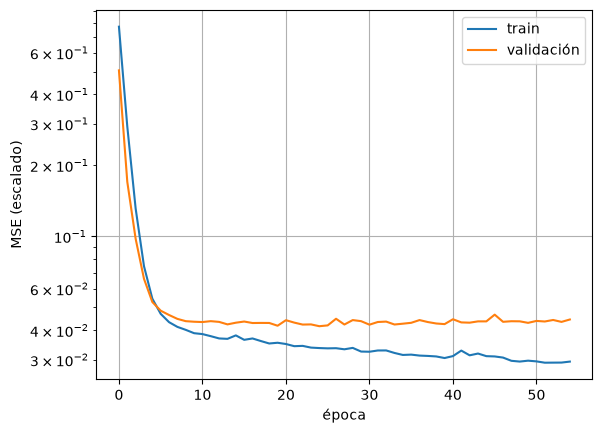

In [7]:
perdida_fn = nn.MSELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-4)

historial = {"train": [], "val": []}
mejor_val, mejor_estado, paciencia, sin_mejora = float("inf"), None, 30, 0

for epoca in range(500):
    modelo.train()
    total = 0.0
    for xb, yb in cargador:
        xb, yb = xb.to(dispositivo), yb.to(dispositivo)
        optimizador.zero_grad()
        perdida = perdida_fn(modelo(xb), yb)
        perdida.backward()
        optimizador.step()
        total += perdida.item() * len(xb)
    historial["train"].append(total / len(cargador.dataset))

    modelo.eval()
    with torch.no_grad():
        val = perdida_fn(modelo(Xva.to(dispositivo)), yva.to(dispositivo)).item()
    historial["val"].append(val)

    if val < mejor_val:
        mejor_val, sin_mejora = val, 0
        mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
    else:
        sin_mejora += 1
        if sin_mejora >= paciencia:
            print(f"Early stopping en la época {epoca}")
            break

modelo.load_state_dict(mejor_estado)
plt.plot(historial["train"], label="train"); plt.plot(historial["val"], label="validación")
plt.yscale("log"); plt.xlabel("época"); plt.ylabel("MSE (escalado)"); plt.legend(); plt.grid(True)
plt.show()

### 4.4 Evaluar en test y comparar con scikit-learn

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

modelo.eval()
with torch.no_grad():
    pred = escala_y.inverse_transform(modelo(Xte.to(dispositivo)).cpu().numpy())

print(f"MAE : {mean_absolute_error(y_test, pred):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred):,.0f}")
print(f"R²  : {r2_score(y_test, pred):.3f}")

MAE : 14,742
RMSE: 19,290
R²  : 0.964


> Compara con el Gradient Boosting del notebook 02. En **datos tabulares pequeños**, los modelos de árboles
> suelen igualar o superar a las redes neuronales con mucho menos esfuerzo. PyTorch brilla con imágenes,
> texto, audio, series temporales, o cuando necesitas arquitecturas a medida (p. ej. redes informadas por la física).

### Guardar el modelo
Se guarda el `state_dict` (los pesos), no el objeto entero.

In [9]:
torch.save(modelo.state_dict(), "red_precios.pt")
nuevo = RedPrecios(Xtr.shape[1])
nuevo.load_state_dict(torch.load("red_precios.pt", weights_only=True))
nuevo.eval();

## Resumen
| Concepto | Scikit-learn | PyTorch |
|---|---|---|
| Entrenar | `modelo.fit(X, y)` | ciclo manual: `zero_grad/forward/loss/backward/step` |
| Datos | NumPy / Pandas / Polars | `torch.Tensor` + `DataLoader` |
| Modelos | catálogo listo | los construyes con `nn.Module` |
| Mejor para | datos tabulares, modelos clásicos | deep learning, GPU, arquitecturas propias |

## ✏️ Ejercicios
1. Cambia el tamaño de las capas ocultas (16, 128) y añade `nn.Dropout(0.1)`. ¿Mejora la validación?
2. Sustituye `Adam` por `SGD(lr=0.01, momentum=0.9)` y compara las curvas de pérdida.
3. Convierte la red en un **clasificador** (casa cara / barata): última capa con 1 salida + `nn.BCEWithLogitsLoss`.
4. Reescribe la sección 3 para ajustar un polinomio de grado 3 con autograd.